In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1. Load MNIST Dataset
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),  # scales to [0,1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 55.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.41MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.54MB/s]


In [2]:

# ----------------------------
# 2. Define Autoencoder Model
# ----------------------------
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Stride=2 does the pooling
        # Encoder
        self.encoder = nn.Sequential(
    nn.Conv2d(1, 16, 3, stride=1, padding=1),  # (28x28) -> (28x28)
    nn.ReLU(),
    nn.MaxPool2d(2),                           # -> (14x14)

    nn.Conv2d(16, 32, 3, stride=1, padding=1), # (14x14) -> (14x14)
    nn.ReLU(),
    nn.MaxPool2d(2)                            # -> (7x7)
)

        # Decoder
        self.decoder = nn.Sequential(
    nn.Upsample(scale_factor=2, mode='nearest'),   # (7x7) -> (14x14)
    nn.Conv2d(32, 16, 3, padding=1),
    nn.ReLU(),

    nn.Upsample(scale_factor=2, mode='nearest'),   # (14x14) -> (28x28)
    nn.Conv2d(16, 1, 3, padding=1),
    nn.Sigmoid()
)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder().to(device)


In [3]:

# ----------------------------
# 3. Loss & Optimizer
# ----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# 4. Training Loop
# ----------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5], Loss: 0.0247
Epoch [2/5], Loss: 0.0050
Epoch [3/5], Loss: 0.0041
Epoch [4/5], Loss: 0.0037
Epoch [5/5], Loss: 0.0034


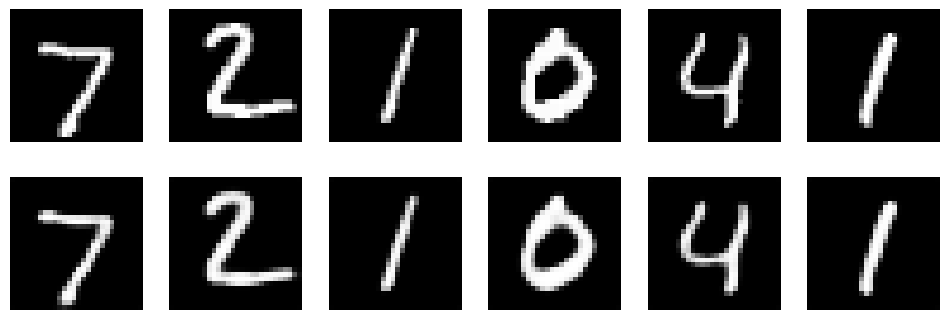

In [4]:

# ----------------------------
# 5. Visualization
# ----------------------------
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    outputs = model(images)

# Move to CPU for plotting
images = images.cpu()
outputs = outputs.cpu()

# Plot original vs reconstructed
n = 6
plt.figure(figsize=(12,4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i+1+n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

# WIth more layers,

Added 3 more Conv2D layers in the encoder
4 more Conv2D layers were added in the decoder to mirror depth --> 64 channels. This would give it the ability to capure more spatial depth

In [5]:
# ----------------------------
# 2. Define Improved Autoencoder Model
# ----------------------------
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder (deeper)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # (28x28)
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),  # extra layer
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (14x14)

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),  # extra layer
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (7x7)

            nn.Conv2d(32, 64, 3, padding=1),  # deeper latent features
            nn.ReLU()
        )

        # Decoder (mirrored depth)
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'),  # (7x7) -> (14x14)
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'),  # (14x14) -> (28x28)
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder().to(device)

In [6]:

# ----------------------------
# 3. Loss & Optimizer
# ----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# 4. Training Loop
# ----------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5], Loss: 0.1146
Epoch [2/5], Loss: 0.1120
Epoch [3/5], Loss: 0.1120
Epoch [4/5], Loss: 0.1120
Epoch [5/5], Loss: 0.1120


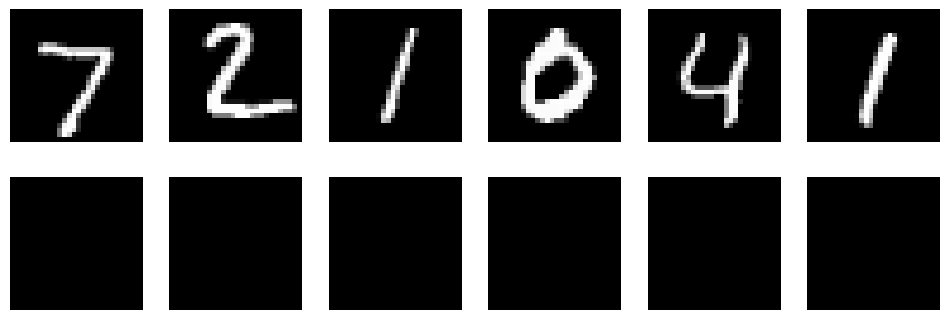

In [7]:

# ----------------------------
# 5. Visualization
# ----------------------------
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    outputs = model(images)

# Move to CPU for plotting
images = images.cpu()
outputs = outputs.cpu()

# Plot original vs reconstructed
n = 6
plt.figure(figsize=(12,4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i+1+n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

# Discussion:
It seems that adding more layers doesnt necessarily improve its ability to capture spatial details. Furhtermore, as one can see during the training process, the loss did not go down.

Let's try again with a smaller LR and more epchs

In [8]:

# ----------------------------
# 3. Loss & Optimizer
# ----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# ----------------------------
# 4. Training Loop
# ----------------------------
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.1120
Epoch [2/10], Loss: 0.1120
Epoch [3/10], Loss: 0.1120
Epoch [4/10], Loss: 0.1120
Epoch [5/10], Loss: 0.1120
Epoch [6/10], Loss: 0.1120
Epoch [7/10], Loss: 0.1120
Epoch [8/10], Loss: 0.1120
Epoch [9/10], Loss: 0.1120
Epoch [10/10], Loss: 0.1120


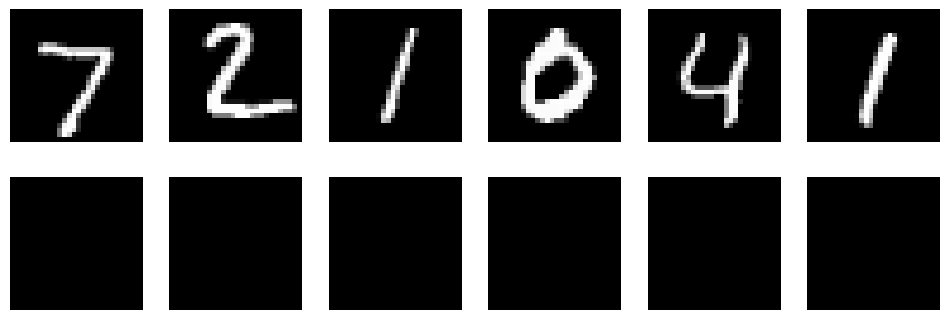

In [9]:

# ----------------------------
# 5. Visualization
# ----------------------------
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    outputs = model(images)

# Move to CPU for plotting
images = images.cpu()
outputs = outputs.cpu()

# Plot original vs reconstructed
n = 6
plt.figure(figsize=(12,4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i+1+n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

Discussion:
That did not help either, seems the issue is in the model architecture. THe model must be underfitting!

Adding BatchNorm as the model seems to be underfitting!

In [10]:
# ----------------------------
# 2. Define Improved Autoencoder Model
# ----------------------------
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder (deeper)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),   # (28x28)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),  # extra layer
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (14x14)

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),  # extra layer
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # -> (7x7)

            nn.Conv2d(32, 64, 3, padding=1),  # deeper latent features
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Decoder (mirrored depth)
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'),  # (7x7) -> (14x14)
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='nearest'),  # (14x14) -> (28x28)
            nn.Conv2d(16, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),

            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder().to(device)

In [11]:

# ----------------------------
# 3. Loss & Optimizer
# ----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# ----------------------------
# 4. Training Loop
# ----------------------------
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 0.1946
Epoch [2/10], Loss: 0.1296
Epoch [3/10], Loss: 0.0948
Epoch [4/10], Loss: 0.0715
Epoch [5/10], Loss: 0.0550
Epoch [6/10], Loss: 0.0430
Epoch [7/10], Loss: 0.0341
Epoch [8/10], Loss: 0.0273
Epoch [9/10], Loss: 0.0221
Epoch [10/10], Loss: 0.0181


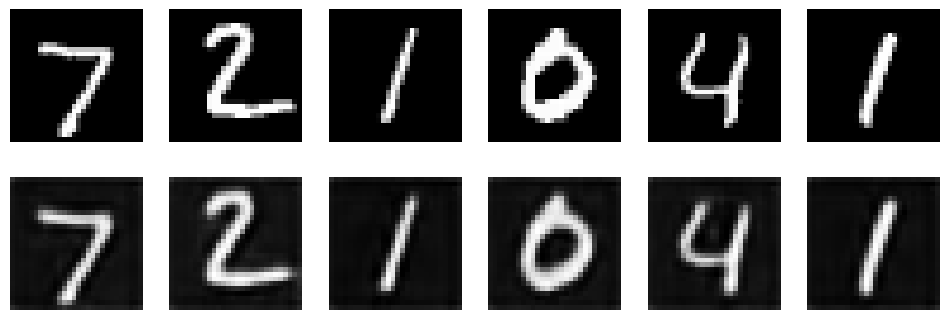

In [12]:

# ----------------------------
# 5. Visualization
# ----------------------------
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    outputs = model(images)

# Move to CPU for plotting
images = images.cpu()
outputs = outputs.cpu()

# Plot original vs reconstructed
n = 6
plt.figure(figsize=(12,4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i+1+n)
    plt.imshow(outputs[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

Discussion:
Finally, the training seems to happen properly as the losses are decreasigng with each epoch. Adding BatchNorm2D After each convolution layer improved the training process.

Though, adding more layers did not make improve the image quality as the original model had more crisp image quality. This one is more blurry.